# Building a Neural Network from Scratch

We are going to write a neural network that can look at a handwritten digit and tell us which number it is. Not by using a library that does it for us, but by writing every piece ourselves, from the maths up.

By the end of Day 2 we will have a working `NeuralNetwork` class. In Day 3 we will train it on real data and see what it can learn.

The approach here is to build each piece as a standalone function, test it, understand it, and only at the end collect everything into a class. That way, when you write the class, you are not guessing — you have already seen every method work.

---

## Day 1

### Part 1: The Data

Before we build anything, let us look at what we are trying to classify.

The MNIST dataset is a collection of 70,000 handwritten digits. Each digit has been photographed and rescaled to a 28×28 grid of pixel values. The pixel values run from 0 (white) to 255 (black). We normalise them to the range 0–1 before feeding them into a network.

Each image comes with a **label** — the actual digit it represents. Our job is to build something that can look at the pixels and guess the label.

The code below loads a sample from a CSV file and shows you some examples. Run it, look at the images, and notice what you are working with: each digit is just a flat list of 784 numbers.

In [31]:
!pip install matplotlib


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
# Provided: loading MNIST data from a CSV file.
# Each row has 785 values: the label first, then 784 pixel values.

def load_mnist_csv(filepath, max_rows=500):
    data = []
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line or not line[0].isdigit():
                continue
            parts = line.split(',')
            label = int(parts[0])
            pixels = [int(p) / 255.0 for p in parts[1:]]
            if len(pixels) == 784:
                data.append((label, pixels))
            if len(data) >= max_rows:
                break
    return data

In [33]:
# Provided: visualisation helpers.  

import matplotlib.pyplot as plt

def show_digit(pixels, label=None):
    grid = [pixels[i * 28:(i + 1) * 28] for i in range(28)]
    plt.figure(figsize=(2, 2))
    plt.imshow(grid, cmap='gray_r')
    plt.axis('off')
    if label is not None:
        plt.title(f'Label: {label}', fontsize=10)
    plt.show()

def show_sample(data, n=10):
    fig, axes = plt.subplots(1, n, figsize=(n * 1.5, 2))
    for i, ax in enumerate(axes):
        if i >= len(data):
            ax.axis('off')
            continue
        label, pixels = data[i]
        ax.imshow([pixels[j * 28:(j + 1) * 28] for j in range(28)], cmap='gray_r')
        ax.axis('off')
        ax.set_title(str(label), fontsize=10)
    plt.tight_layout()
    plt.show()

Loaded 200 examples.
Each input is a list of 784 values.
Labels range from 0 to 9.


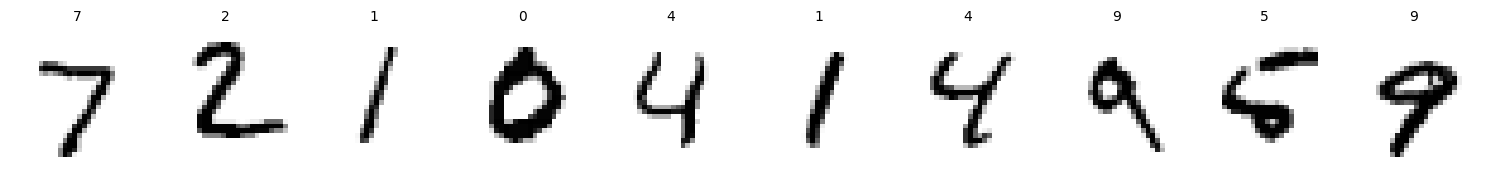

In [34]:
# Load the data.
# Replace this path with wherever your MNIST CSV file lives.
data = load_mnist_csv('mnist_test.csv', max_rows=200)

print(f'Loaded {len(data)} examples.')
print(f'Each input is a list of {len(data[0][1])} values.')
print(f'Labels range from {min(d[0] for d in data)} to {max(d[0] for d in data)}.')

show_sample(data, n=10)

Look at those ten images. Each one is genuinely different — different handwriting, different thickness, different angle. The network we build will have to learn what it means for a clump of pixels to be a "3" versus a "5" just from the numbers.

Before you move on: how would *you* tell a 1 from a 7? What features are you actually using?

---

### Part 2: What Our Network Will Look Like

A neural network is a chain of layers. Each layer takes a list of numbers as input, does some arithmetic, and passes the result to the next layer.

Our network will have this shape:

- **Input layer**: 784 values — one per pixel
- **Hidden layer 1**: 128 values
- **Hidden layer 2**: 64 values
- **Output layer**: 10 values — one per digit (0 through 9)

The output layer will give us ten numbers. The largest one is our prediction: whichever digit has the highest score is the one the network thinks it is looking at.

Between every pair of adjacent layers, every node in one layer is connected to every node in the next. Each connection has a **weight** — a number that controls how much influence one node has on another. Each node also has a **bias** — a value that shifts its output up or down regardless of the input.

The weights and biases start as small random numbers. Training means adjusting them until the network gets better at recognising digits.

We will build this piece by piece.

---

### Part 3: Random Matrices

The first thing we need is a way to create a matrix of small random numbers. A matrix here is a list of lists: each inner list is one row.

We use small numbers near zero for initialisation so that the network does not immediately produce enormous outputs before it has learned anything.

In [35]:
import random

def random_matrix(rows:int, cols:int)->list[list[float]]:
    """
    Return a matrix with the given number of rows and columns,
    filled with random floats between -0.1 and 0.1.
    """
    # Your code here.
    random_matrix = [] # empty list to hold the rows of the matrix
    for i in range(rows): # Loop over the number of rows
        row = [random.uniform(-0.1, 0.1) 
               for r in range(cols)] # Create a row with cols random floats between -0.1 and 0.1
        random_matrix.append(row)
    return random_matrix


In [36]:
# Test it.
m = random_matrix(3, 4)
print(f'Rows: {len(m)}')
print(f'Columns: {len(m[0])}')
print(f'First row: {m[0]}')
print(f'All values between -0.1 and 0.1: {all(-0.1 <= v <= 0.1 for row in m for v in row)}')

Rows: 3
Columns: 4
First row: [0.04416026754165456, 0.08797874092842187, -0.018922909552866754, 0.047192868580356706]
All values between -0.1 and 0.1: True


---

### Part 4: Weighted Sum

Each node in the network computes a **weighted sum** of its inputs. If the inputs are `[x0, x1, x2]` and the weights for one particular node are `[w0, w1, w2]` with bias `b`, that node's output (before any activation) is:

```
z = w0*x0 + w1*x1 + w2*x2 + b
```

This is also called a dot product plus a bias. You may have written a dot product before — it is exactly that, with `b` added at the end.

In [37]:
def weighted_sum(weights:list[float], inputs:list[float], bias:float)->float:
    """
    Compute the dot product of weights and inputs, then add bias.
    
    weights: a list of floats, one per input
    inputs:  a list of floats, one per input
    bias:    a single float
    
    Returns a single float.
    """
    # Your code here.    
   
    dot_product = 0.0 # starting dot product to zero
    dot_product = sum(weights[i] * inputs[i] # Compute the dot product of weights and inputs
          for i in range(len(weights))) # Loop over the indices of weights and inputs
    return dot_product + bias 


In [38]:
# Test it.
# 0.5*1.0 + (-0.3)*2.0 + 0.8*0.5 + 0.1
# = 0.5 - 0.6 + 0.4 + 0.1
# = 0.4

result = weighted_sum([0.5, -0.3, 0.8], [1.0, 2.0, 0.5], 0.1)
print(f'Result: {result}')
print(f'Expected: 0.4')

Result: 0.4
Expected: 0.4


---

### Part 5: Activation Functions

After computing a weighted sum, we pass the result through an **activation function**. Without this step, a neural network with multiple layers would collapse into a single linear transformation — adding more layers would not help. Activation functions introduce the non-linearity that lets deep networks learn complex patterns.

**ReLU** (Rectified Linear Unit) is the one we will use in our hidden layers. It is extremely simple: if the input is positive, pass it through unchanged. Otherwise, return zero.

In [39]:
def relu(x:float)->float:
    """
    Return x if x is positive, otherwise return 0.
    """
    # Your code here.
    if x > 0:
        return x
    else:
        return 0
    

In [40]:
# Test it.
for val in [-2.0, -0.5, 0.0, 0.3, 1.7]:
    print(f'relu({val:5.1f}) = {relu(val)}')

relu( -2.0) = 0
relu( -0.5) = 0
relu(  0.0) = 0
relu(  0.3) = 0.3
relu(  1.7) = 1.7


**Softmax** is what we will use on the output layer. It takes a list of numbers and converts them into a probability distribution: values between 0 and 1 that sum to exactly 1. The digit with the highest softmax score is the one the network is "most confident" about.

The formula is:

```
softmax(z_i) = exp(z_i) / sum(exp(z_j) for all j)
```

We subtract the maximum value before exponentiating — this is a standard numerical stability trick that prevents overflow and does not change the result.

In [41]:
import math

def softmax(values:list[float])->list[float]:
    """
    Convert a list of values into a probability distribution.
    
    Subtract the maximum value first (numerical stability).
    Then exponentiate each value and divide by the total.
    
    Returns a list of floats that sum to 1.0.
    """
    # Your code here.
    maximum_value = max(values) # Find maximum value
    exponentiated_values = [math.exp(value - maximum_value) # Exponentiate each value
    for value in values] # Loop over the values to create a new list of exponentiated values
    total = sum(exponentiated_values) #Total of exp values
    soft_max_values = [value / total for value in exponentiated_values]
    return soft_max_values

In [42]:
# Test it.
scores = [2.0, 1.0, 0.5]
probs = softmax(scores)
print(f'Probabilities: {[round(p, 4) for p in probs]}')
print(f'Sum: {round(sum(probs), 8)}')  # Should be 1.0

# The highest score (2.0) should have the highest probability.
# The values should all be positive.

Probabilities: [0.6285, 0.2312, 0.1402]
Sum: 1.0


---

### Part 6: Setting Up the Network

We now have the building blocks. The next step is to set up the data structure that will hold our network's weights and biases.

Given a list of layer sizes like `[784, 128, 64, 10]`, we need:
- A weight matrix **between each pair of adjacent layers**
- A bias vector **for each layer except the input**

For our network:
- Weights from layer 0 to layer 1: 128 rows × 784 columns (each of the 128 nodes needs one weight per input)
- Weights from layer 1 to layer 2: 64 rows × 128 columns
- Weights from layer 2 to layer 3: 10 rows × 64 columns

Notice the pattern: for a connection from a layer of size `a` to a layer of size `b`, the weight matrix has shape `b × a`.

In [43]:
def make_network(layer_sizes:list[int])->dict[str, list]:
    """
    Given a list of layer sizes, return a dict with:
    - 'layer_sizes': the original list
    - 'weights': a list of weight matrices (one per pair of adjacent layers)
    - 'biases':  a list of bias vectors (one per non-input layer)
    
    Initialise weights using random_matrix.
    Initialise biases as lists of zeros.
    """
    # Your code here.
    list_of_weight_matrices = [] # List to hold weight matrices for each layer
    list_of_bias_vectors = [] # List to hold bias vectors for each layer
    for i in range(len(layer_sizes) - 1): # Loop over the layer sizes, stopping before the last one(-1)
        input_size = layer_sizes[i] #Input size for the layer
        output_size = layer_sizes[i + 1] #Output size for the layer(+1)
        weights = random_matrix(output_size, input_size) # Create a weight matrix for the layer with dimensions
        list_of_weight_matrices.append(weights) 
        biases = [0.0] * output_size # Create a bias vector for layer with output size
        list_of_bias_vectors.append(biases) 
    return {
        'layer_sizes': layer_sizes, 
        'weights': list_of_weight_matrices,
        'biases': list_of_bias_vectors
    }
    

In [44]:
# Test it.
net = make_network([784, 128, 64, 10])

print(f'Number of weight matrices: {len(net["weights"])}')

for i, (W, b) in enumerate(zip(net['weights'], net['biases'])):
    print(f'  Layer {i + 1}: weights {len(W)} x {len(W[0])}, biases length {len(b)}')

Number of weight matrices: 3
  Layer 1: weights 128 x 784, biases length 128
  Layer 2: weights 64 x 128, biases length 64
  Layer 3: weights 10 x 64, biases length 10


---

### Part 7: Describing the Network

Before we use our network, let us write a function that describes it clearly: what shape are the layers, and how many parameters does it have in total?

A weight matrix with `rows` rows and `cols` columns has `rows * cols` parameters. Each bias vector of length `n` has `n` parameters.

In [45]:
def describe_network(net):
    """
    Print a summary: the shape of each weight matrix, the length of
    each bias vector, and the total number of parameters.
    """
    total = 0
    for i, (W, b) in enumerate(zip(net['weights'], net['biases'])): 
        params = len(W) * len(W[0]) + len(b) 
        total += params 
        print(f'  Layer {i + 1}: {len(W[0])} inputs -> {len(W)} nodes  ({params:,} parameters)')
    print(f'\n  Total parameters: {total:,}')

In [46]:
net = make_network([784, 128, 64, 10])
describe_network(net)

  Layer 1: 784 inputs -> 128 nodes  (100,480 parameters)
  Layer 2: 128 inputs -> 64 nodes  (8,256 parameters)
  Layer 3: 64 inputs -> 10 nodes  (650 parameters)

  Total parameters: 109,386


Think about that number for a moment. Every one of those parameters will be adjusted during training.

---

### Part 8: One Layer Forward

Now let us move data through a single layer. Given:
- A list of input values
- The weight matrix for this layer
- The bias vector for this layer
- An activation function

...we compute two things:
1. The **pre-activation output** — the raw weighted sums, before the activation function
2. The **post-activation output** — after applying the activation function

We return both because we will need the pre-activation values when we do backpropagation in Day 2.

In [47]:
def forward_layer(inputs:list[float], weights:list[list[float]], biases:list[float], activation):
    """
    Compute the output of one layer.
    
    inputs:     list of floats (input to this layer)
    weights:    list of lists (each inner list is one node's weights)
    biases:     list of floats (one bias per node in this layer)
    activation: a function to apply element-wise after the weighted sums
    
    Returns: (pre_activation, post_activation)
    Both are lists of floats, one value per node in this layer.
    """
    # For each node in this layer:
    #   compute weighted_sum(weights[node], inputs, biases[node])
    # Collect those into pre_activation.
    # Apply activation to each value to get post_activation.
    # Return both.
    list_of_pre_activations = [] # empty list for pre activation values for each node in this layer
   
    for node_weights, node_bias in zip(weights, biases): #loop over each node weights and bias
        pre_activation = weighted_sum(node_weights, inputs, node_bias) # weighted sum for this node
        list_of_pre_activations.append(pre_activation) 
    
    if activation == softmax:
        post_activation = softmax(list_of_pre_activations)
    else:
        post_activation = [activation(p) # Apply activation function to each pre-activation value
            for p in list_of_pre_activations] #loop for p to create a new list of post-activation
    return list_of_pre_activations, post_activation


    

In [48]:
# Test it with a tiny example.
W = [[0.5, -0.3],
     [0.2,  0.8]]    # 2 nodes, each with 2 weights
b = [0.1, -0.1]
inputs = [1.0, 0.5]

pre, post = forward_layer(inputs, W, b, relu)

print(f'Pre-activation: {pre}')
print(f'Post-activation: {post}')

# Check by hand:
# Node 0: 0.5*1.0 + (-0.3)*0.5 + 0.1 = 0.5 - 0.15 + 0.1 = 0.45  -> relu(0.45) = 0.45
# Node 1: 0.2*1.0 +   0.8*0.5 - 0.1 = 0.2 + 0.40 - 0.1 = 0.50  -> relu(0.50) = 0.50

Pre-activation: [0.44999999999999996, 0.5000000000000001]
Post-activation: [0.44999999999999996, 0.5000000000000001]


---

### Part 9: Full Forward Pass

Now let us pass an input all the way through every layer. Hidden layers use ReLU; the output layer uses softmax.

In [49]:
def forward(net: dict, inputs: list[float]):
    """
    Pass inputs through all layers of the network.
    
    Use relu for all layers except the last, which uses softmax.
    
    Returns a list of (pre_activation, post_activation) tuples,
    one per non-input layer.
    
    The final post_activation is the network's raw output —
    ten probability values, one per digit.
    """
    # Start with the inputs.
    # For each layer in the network:
    #   determine which activation to use (relu or softmax)
    #   call forward_layer
    #   the output of this layer becomes the input to the next
    # Collect and return all the (pre, post) pairs.
    list_of_pre_post = [] #list for tupel of values for each layer
    current_inputs = inputs # Starting with the inputs.
    num_layers = len(net["layer_sizes"])    
    for layer_number in range(num_layers): # Loop over the layers of network
        weights = net['weights'][i] #getting weights for layer [i]
        biases = net['biases'][i] #getting biases for layer [i]
        if layer_number == len(net['weights']) - 1: # If this is the last layer,we are going to use softmax
            activation = softmax
        else:
            activation = relu #for other we are using relu     
        pre, post = forward_layer(current_inputs, weights, biases, activation) #forward layer for this layer
        list_of_pre_post.append((pre, post))
        
    
    return list_of_pre_post

In [50]:
# Test it: pass a random 784-value input through the full network.
test_input = [random.uniform(0, 1) for _ in range(784)]
layer_outputs = forward(net, test_input)

print(f'Number of layer outputs: {len(layer_outputs)}')
print(f'Final output length: {len(layer_outputs[-1][1])}')
print(f'Sum of output probabilities: {round(sum(layer_outputs[-1][1]), 6)}')

# Show the output as a bar chart.
probs = layer_outputs[-1][1]
for digit, p in enumerate(probs):
    bar = '#' * int(p * 50)
    print(f'  {digit}: {bar:<50} {p:.4f}')

Number of layer outputs: 4
Final output length: 10
Sum of output probabilities: 1.065252
  0:                                                    0.0000
  1:                                                    0.0140
  2:                                                    0.0000
  3: ###################################                0.7071
  4:                                                    0.0000
  5:                                                    0.0078
  6:                                                    0.0000
  7:                                                    0.0000
  8:                                                    0.0000
  9: ################                                   0.3364


The probabilities sum to 1 because of softmax. The network's prediction at this point is essentially random — the weights are random, so every digit is roughly equally likely. That is exactly where we should be.

That is the end of Day 1.

---

## Day 2

### Part 10: Predicting a Digit

We have a forward pass. Now let us turn the output into an actual prediction: which digit does the network think it is looking at?

The answer is simply the index of the highest probability. If the output layer gives the highest value to index 3, the network's prediction is "3".

In [51]:
def predict(net: dict, inputs: list[float]):
    """
    Run inputs through the network and return the predicted digit.
    
    Use your forward function to get the output probabilities.
    Return the index of the maximum value in the output.
    """
    # Your code here.
    layer_outputs = forward(net, inputs) # Running inputs through the network to get layer outputs
    final_output = layer_outputs[-1][1] # Getting final output probabilities from the last layer
    predict_digit = final_output.index(max(final_output)) #Return index to max value
    
    return predict_digit


In [52]:
# Test it on a few examples from the dataset.
# At this point the predictions will almost certainly be wrong —
# the network has not learned anything yet.
for label, pixels in data[:8]:
    pred = predict(net, pixels)
    correct = '✓' if pred == label else '✗'
    print(f'  True label: {label}   Prediction: {pred}   {correct}')

  True label: 7   Prediction: 0   ✗
  True label: 2   Prediction: 0   ✗
  True label: 1   Prediction: 0   ✗
  True label: 0   Prediction: 0   ✓
  True label: 4   Prediction: 0   ✗
  True label: 1   Prediction: 0   ✗
  True label: 4   Prediction: 0   ✗
  True label: 9   Prediction: 0   ✗


Wrong predictions at this stage are expected and normal. We need a way to measure how wrong, and then a way to correct the weights.

---

### Part 11: How Wrong Are We? (Loss)

To train a network, we need a number that captures how bad a given prediction was. That number is called the **loss**.

We use **cross-entropy loss**. The idea is simple: if the network assigned probability `p` to the correct class, the loss is `-log(p)`. If `p` is close to 1 (confident and correct), the loss is close to 0. If `p` is close to 0 (confident and wrong), the loss is very large.

```
L = -log(p_correct)
```

In [53]:
def cross_entropy_loss(output_probs: list, label: int)-> float:
    """
    Compute the cross-entropy loss for one prediction.
    
    output_probs: the softmax output, a list of 10 floats
    label:        the correct class as an integer (0-9)
    
    Returns a single float.
    
    Hint: add a tiny value (1e-12) inside the log to avoid log(0).
    """
    # Your code here.
    
    label_prob = output_probs[label] # Geting the probability of correct class
    loss = -math.log(label_prob+1e-12) # avoiding log(0) and Count loss


    return loss
    

In [54]:
# Test it.
# If the network assigns probability 1.0 to the correct class, loss should be 0.
# If it assigns 0.1 (ten percent), loss should be higher.

perfect = [0.0] * 10
perfect[3] = 1.0
print(f'Loss when correct class gets 1.0:  {cross_entropy_loss(perfect, 3):.4f}')

uncertain = [0.1] * 10
print(f'Loss when correct class gets 0.1:  {cross_entropy_loss(uncertain, 3):.4f}')

# Try constructing a case where the network is confident but wrong.
# What is the loss?

Loss when correct class gets 1.0:  -0.0000
Loss when correct class gets 0.1:  2.3026


---

### Part 12: Fixing the Weights (Backpropagation)

We know how wrong we were. Now we need to fix the weights.

**Backpropagation** is the method. The idea is to work backwards through the network, computing how much each weight contributed to the error, then nudging each weight slightly in the direction that would reduce it. The size of each nudge is controlled by the **learning rate** — a small number, typically something like 0.01.

This uses the chain rule from calculus. The cross-entropy loss and softmax combine to give a particularly clean expression for the output layer gradient:

```
delta_output[i] = output[i] - target[i]
```

where `target` is the one-hot vector for the correct class (all zeros except a 1 at the correct index). For subsequent layers we propagate this delta backwards, multiplying by the weights and by the derivative of ReLU at each step.

The derivative of ReLU is 1 where the pre-activation value was positive, and 0 otherwise.

The function below is provided. Read through it carefully. Notice:

- We save the current weights **before** updating them. Think about why this matters before moving on.
- We work backwards through the layers using `range(n_layers - 1, -1, -1)`.
- Each step computes a new `delta` for the layer below using the saved weights.

In [55]:
# Provided: backpropagation.
# Read through this carefully before moving to Part 13.

def backprop(net, inputs, label, layer_outputs, learning_rate=0.01):
    """
    Update the weights and biases in net using one training example.
    
    net:           the network dict (modified in place)
    inputs:        the original input vector
    label:         the correct digit (integer, 0-9)
    layer_outputs: the (pre, post) pairs returned by forward()
    learning_rate: step size for weight updates
    """
    n_layers = len(net['weights'])

    # One-hot target: all zeros except a 1 at the correct class.
    target = [0.0] * 10
    target[label] = 1.0

    # Output layer gradient: cross-entropy + softmax simplify to output - target.
    output_probs = layer_outputs[-1][1]
    delta = [output_probs[i] - target[i] for i in range(len(output_probs))]

    for layer_idx in range(n_layers - 1, -1, -1):

        # The input to this layer is either the original input (layer 0)
        # or the post-activation output of the previous layer.
        if layer_idx == 0:
            layer_input = inputs
        else:
            layer_input = layer_outputs[layer_idx - 1][1]

        # Save current weights before updating.
        # We need the original weights to compute the gradient for the layer below.
        saved_weights = [row[:] for row in net['weights'][layer_idx]]

        # Update each weight and bias.
        for j in range(len(net['weights'][layer_idx])):
            for k in range(len(net['weights'][layer_idx][j])):
                # The gradient of the loss with respect to this weight is
                # delta[j] * layer_input[k].
                net['weights'][layer_idx][j][k] -= learning_rate * delta[j] * layer_input[k]
            net['biases'][layer_idx][j] -= learning_rate * delta[j]

        # Compute delta for the layer below (chain rule).
        if layer_idx > 0:
            pre_activation = layer_outputs[layer_idx - 1][0]
            new_delta = []
            for k in range(len(layer_input)):
                # Sum contributions from all nodes in the current layer.
                grad = sum(saved_weights[j][k] * delta[j]
                           for j in range(len(delta)))
                # ReLU's derivative: 1 if pre-activation was positive, else 0.
                relu_deriv = 1.0 if pre_activation[k] > 0 else 0.0
                new_delta.append(grad * relu_deriv)
            delta = new_delta

Before moving on, answer these two questions in the cell below:

1. Why do we save the weights before updating them? What would go wrong if we used the already-updated weights when computing the next layer's delta?

2. The output layer gradient simplifies to `output[i] - target[i]`. What does this expression equal when the network assigns a very high probability to the correct class?

In [56]:
# Write your answers here as comments or a print statement.
""" Q1: If we updated the weights in place before computind the new delta,
we would be using updated weights instead of the original ones,
that would give us incorrect gradients and prevent network from learning properly.
    Q2: output[i] is close to 1 for the correct class and close to 0 for incorrect classes.
For the correct class, output[i] - target[i] will be close to 0"""

' Q1: If we updated the weights in place before computind the new delta,\nwe would be using updated weights instead of the original ones,\nthat would give us incorrect gradients and prevent network from learning properly.\n    Q2: output[i] is close to 1 for the correct class and close to 0 for incorrect classes.\nFor the correct class, output[i] - target[i] will be close to 0'

---

### Part 13: The Training Loop

We have forward, loss, and backprop. Now we can write a training loop that puts them all together.

The loop goes through the training data one example at a time, runs a forward pass, records the loss and whether the prediction was correct, and runs backprop to update the weights. We record the loss and accuracy as we go so we can see whether the network is improving.

In [57]:
def train(net, data, epochs=1, learning_rate=0.01):
    """
    Train the network on data for the given number of epochs.
    
    An epoch is one full pass through all the training examples.
    
    For each example:
    1. Run forward() to get layer_outputs*.
    2. Record the loss* using cross_entropy_loss*.
    3. Record whether predict()* returns the correct label.
    4. Run backprop() to update the weights.
    
    Print the average loss and accuracy after each epoch.
    
    Returns (loss_history, accuracy_history), where each is a list
    of per-example values across all epochs.
    """
    loss_history = []
    accuracy_history = []

    for epoch in range(epochs):
        epoch_loss = 0.0
        epoch_correct = 0

        for label, pixels in data:
            # Your code here.
            layer_outputs = forward(net, pixels) # Running forward pass to get layer outputs
            output_probs = layer_outputs[-1][1] # Getting final output probabilities
            loss = cross_entropy_loss(output_probs, label) # Compute loss
            loss_history.append(loss) # recording loss(2)
            
            pred = predict(net, pixels) # Getting the predicted label
            correct = (pred == label) # Check if prediction is correct
            accuracy_history.append(correct) # recording corret to history(3)

            backprop(net, pixels, label, layer_outputs, learning_rate) # Running backpropagation for updating the weights


        avg_loss = epoch_loss / len(data)
        avg_acc = epoch_correct / len(data)
        print(f'Epoch {epoch + 1}: loss = {avg_loss:.4f}   accuracy = {avg_acc:.2%}')

    return loss_history, accuracy_history

In [58]:
# Test it: train for a few epochs on our 200-example dataset.
# With only 200 examples and a randomly initialised network,
# do not expect dramatic results — but you should see the loss
# moving in the right direction.
net = make_network([784, 128, 64, 10])
losses, accs = train(net, data, epochs=3, learning_rate=0.01)

IndexError: list index out of range

---

### Part 14: Testing with a Random Input

Before we move to the full dataset (that is Day 3), let us do a final sanity check: feed a random 784-value input through the trained network and look at what comes out.

In [ ]:
# Create a random input the right size.
random_input = [random.uniform(0, 1) for _ in range(784)]

# Run it through and look at the output.
layer_outputs = forward(net, random_input)
pred = predict(net, random_input)
output_probs = layer_outputs[-1][1]

print(f'Prediction: {pred}')
print(f'Confidence: {output_probs[pred]:.2%}')
print()
print('Full probability distribution:')
for digit, p in enumerate(output_probs):
    bar = '#' * int(p * 50)
    print(f'  {digit}: {bar:<50} {p:.4f}')

Prediction: 5
Confidence: 31.85%

Full probability distribution:
  0:                                                    0.0000
  1: #                                                  0.0243
  2:                                                    0.0000
  3: ##########                                         0.2076
  4:                                                    0.0052
  5: ###############                                    0.3185
  6:                                                    0.0000
  7: #######                                            0.1403
  8: ##                                                 0.0496
  9:                                                    0.0000


---

### Part 15: Assembling the Class

You now have every piece of the network working as a standalone function. Let us bring them all together into a single `NeuralNetwork` class.

Each function you wrote becomes a method. Where a function took `net` as its first argument, that becomes `self`. The internal helpers (random matrix, relu, softmax, weighted sum, forward layer) become private methods prefixed with an underscore.

In [ ]:
import random
import math

class NeuralNetwork:
    """A feedforward neural network for digit classification."""

    def __init__(self, layer_sizes):
        """
        Initialise the network.
        layer_sizes: e.g. [784, 128, 64, 10]
        """
        self.layer_sizes = layer_sizes
        self.weights = []
        self.biases = []
        for i in range(len(layer_sizes) - 1):
            self.weights.append(self._random_matrix(layer_sizes[i + 1], layer_sizes[i]))
            self.biases.append([0.0] * layer_sizes[i + 1])

    def __str__(self):
        """Return a readable summary of the network architecture."""
        # Your code here.

            
      
        pass
    def _random_matrix(self, rows, cols):
        """Return a matrix of random values between -0.1 and 0.1."""
        # Bring your random_matrix function here.

        random_matrix = [] # empty list to hold the rows of the matrix
        for i in range(rows): # Loop over the number of rows
            row = [random.uniform(-0.1, 0.1) 
               for r in range(cols)] # Create a row with cols random floats between -0.1 and 0.1
            random_matrix.append(row)
        return random_matrix
        

        

    def _relu(self, x):
        """Return x if positive, otherwise 0."""
        # Your code here.
        if x > 0:
            return x
        else:
            return 0
        

    def _softmax(self, values):
        """Convert a list of values to a probability distribution."""
        # Your code here.
        maximum_value = max(values) # Find maximum value
        exponentiated_values = [math.exp(value - maximum_value) # Exponentiate each value
        for value in values] # Loop over the values to create a new list of exponentiated values
        
        total = sum(exponentiated_values) #Total of exp values
        soft_max_values = [value / total for value in exponentiated_values]
        return soft_max_values
        

    def _weighted_sum(self, weights, inputs, bias):
        """Dot product of weights and inputs, plus bias."""
        # Your code here.
        dot_product = 0.0 # starting dot product to zero
        dot_product = sum(weights[i] * inputs[i] # Compute the dot product of weights and inputs
          for i in range(len(weights))) # Loop over the indices of weights and inputs
        return dot_product + bias 
        

    def _forward_layer(self, inputs, layer_idx, activation):
        """
        Compute the output of one layer.
        Returns (pre_activation, post_activation).
        """
        # Your code here.        

        pre_activations = [] # empty list for pre activation values for each node in this layer
        #current layer  

        for node_weights, node_bias in zip(self.weights[layer_idx], self.biases[layer_idx]): #loop over each node weights and bias***
            pre_activation = self._weighted_sum(node_weights, inputs, node_bias) # weighted sum for this node
            pre_activations.append(pre_activation) 
    
        if activation == self._softmax:
            post_activation = self._softmax(pre_activations)# Apply softmax activation function to the list of pre-activation values
        else:
            post_activation = [activation(p) for p in pre_activations] # Apply activation function to each pre-activation value
        return pre_activations, post_activation
        

    def forward(self, inputs):
        """
        Pass inputs through all layers.
        Returns a list of (pre, post) tuples, one per non-input layer.
        """
        list_of_pre_post = []
        current_inputs = inputs

        for layer_idx in range(len(self.weights)):
            activation = self._softmax if layer_idx == len(self.weights) - 1 else self._relu
            pre, post = self._forward_layer(current_inputs, layer_idx, activation)
            list_of_pre_post.append((pre, post))
            current_inputs = post # the output of this layer becomes the input to the next
      
    
        return list_of_pre_post
        

    def predict(self, inputs):
        """Return the predicted digit for a given input."""
        # Your code here.
        layer_outputs = self.forward(inputs) # Running inputs through the network to get layer outputs
        final_output = layer_outputs[-1][1] # Getting final output probabilities from the last layer
        predict_digit = final_output.index(max(final_output)) #Return index to max value
    
        return predict_digit
        

    def _cross_entropy_loss(self, output_probs, label):
        """Compute cross-entropy loss for one example."""
        # Your code here.
        label_prob = output_probs[label] # Geting the probability of correct class
        loss = -math.log(label_prob+1e-12) # avoiding log(0) and Count loss



        return loss
        

    def _backprop(self, inputs, label, layer_outputs, learning_rate):
        """
        Update weights using backpropagation.
        Bring across the provided backprop function,
        replacing net['weights'] with self.weights and so on.
        """
        # Your code here.
        n_layers = len(self.weights)

    # One-hot target: all zeros except a 1 at the correct class.
        target = [0.0] * 10
        target[label] = 1.0

    # Output layer gradient: cross-entropy + softmax simplify to output - target.
        output_probs = layer_outputs[-1][1]
        delta = [output_probs[i] - target[i] for i in range(len(output_probs))]

        for layer_idx in range(n_layers - 1, -1, -1):

        # The input to this layer is either the original input (layer 0)
        # or the post-activation output of the previous layer.
            if layer_idx == 0:
                layer_input = inputs
            else:
                layer_input = layer_outputs[layer_idx - 1][1]

        # Save current weights before updating.
        # We need the original weights to compute the gradient for the layer below.
        saved_weights = [row[:] for row in self.weights[layer_idx]]

        # Update each weight and bias.
        for j in range(len(self.weights[layer_idx])):
            for k in range(len(self.weights[layer_idx][j])):
                # The gradient of the loss with respect to this weight is
                # delta[j] * layer_input[k].
                self.weights[layer_idx][j][k] -= learning_rate * delta[j] * layer_input[k]
                self.biases[layer_idx][j] -= learning_rate * delta[j]

        # Compute delta for the layer below (chain rule).
        if layer_idx > 0:
            pre_activation = layer_outputs[layer_idx - 1][0]
            new_delta = []
            for k in range(len(layer_input)):
                # Sum contributions from all nodes in the current layer.
                grad = sum(saved_weights[j][k] * delta[j]
                           for j in range(len(delta)))
                # ReLU's derivative: 1 if pre-activation was positive, else 0.
                relu_deriv = 1.0 if pre_activation[k] > 0 else 0.0
                new_delta.append(grad * relu_deriv)
            delta = new_delta
        

    def train(self, data, epochs=1, learning_rate=0.01):
        """
        Train on data. Print loss and accuracy per epoch.
        Returns (loss_history, accuracy_history).
        """
        # Your code here.
        pass

In [ ]:
# Final test for Day 2.
nn = NeuralNetwork([784, 128, 64, 10])
print(nn)

TypeError: __str__ returned non-string (type NoneType)

In [ ]:
# Quick training run to confirm the class works end-to-end.
losses, accs = nn.train(data, epochs=3, learning_rate=0.01)

In [ ]:
# Test the predict method directly on a few examples.
for label, pixels in data[:5]:
    pred = nn.predict(pixels)
    print(f'  True: {label}   Predicted: {pred}')

That is the end of Day 2. Your `NeuralNetwork` class is complete and working. In Day 3 we will load the full MNIST dataset, train for several epochs, and look carefully at what the network has learned.

---

# Building a Neural Network from Scratch — Day 3

Your `NeuralNetwork` class is complete. Today we use it to run three experiments and think carefully about what happens when a network has too few parameters, too many, or roughly the right number.

If you are still finishing Day 2 parts, that is fine — work through this and come back to tighten earlier cells when there is time.

---

## Setup

Paste your `NeuralNetwork` class in the cell below, or import it. The helpers provided here are all you will need today.

In [ ]:
# Your NeuralNetwork class here (or import it).

import random
import math
import matplotlib.pyplot as plt

In [ ]:
# Provided: data loading.

def load_mnist_csv(filepath, max_rows=None):
    data = []
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line or not line[0].isdigit():
                continue
            parts = line.split(',')
            label = int(parts[0])
            pixels = [int(p) / 255.0 for p in parts[1:]]
            if len(pixels) == 784:
                data.append((label, pixels))
            if max_rows and len(data) >= max_rows:
                break
    return data

In [ ]:
# Provided: plotting and accuracy helpers.

def plot_curves(loss_history, accuracy_history, title='Training'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))
    ax1.plot(loss_history, linewidth=0.8, alpha=0.85)
    ax1.set_title(f'{title} — Loss')
    ax1.set_xlabel('Example (all epochs)')
    ax1.set_ylabel('Loss')
    ax2.plot(accuracy_history, linewidth=0.8, alpha=0.85, color='steelblue')
    ax2.set_title(f'{title} — Running accuracy')
    ax2.set_xlabel('Example (all epochs)')
    ax2.set_ylabel('Accuracy')
    ax2.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()

def accuracy_on(nn, dataset):
    correct = sum(1 for label, pixels in dataset if nn.predict(pixels) == label)
    return correct / len(dataset)

def show_misclassified(nn, test_data, n=12):
    errors = [(label, pixels) for label, pixels in test_data
              if nn.predict(pixels) != label]
    n = min(n, len(errors))
    if n == 0:
        print('No misclassified examples found.')
        return
    cols = 6
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.6, rows * 2.0))
    axes = axes.flat if rows > 1 else [axes] if cols == 1 else axes
    for i, ax in enumerate(axes):
        if i >= n:
            ax.axis('off')
            continue
        label, pixels = errors[i]
        pred = nn.predict(pixels)
        ax.imshow([pixels[j * 28:(j + 1) * 28] for j in range(28)], cmap='gray_r')
        ax.axis('off')
        ax.set_title(f'T:{label}  P:{pred}', fontsize=8, color='firebrick')
    plt.suptitle('Misclassified examples', fontsize=10)
    plt.tight_layout()
    plt.show()
    print(f'{len(errors)} errors out of {len(test_data)} test examples.')

In [ ]:
# Load data and make an 80/20 split.
# Adjust max_rows to taste — 1000 trains in a reasonable time,
# more gives better curves.
all_data   = load_mnist_csv('mnist_train.csv', max_rows=1000)
split      = int(len(all_data) * 0.8)
train_data = all_data[:split]
test_data  = all_data[split:]

print(f'Training:  {len(train_data)} examples')
print(f'Test:      {len(test_data)} examples')

---

## The Experiment

We are going to train three networks on exactly the same data. The only thing that changes is their architecture — the number of layers and nodes.

Before we run anything, look at each architecture and use your `describe_network` function (or the `__str__` method on the class) to see the parameter count. This matters.

In [ ]:
# Three architectures.
tiny   = NeuralNetwork([784,  8,       10])   # very few nodes
medium = NeuralNetwork([784, 64, 32,   10])   # moderate
large  = NeuralNetwork([784, 512, 256, 10])   # many nodes

print('Tiny:')
print(tiny)
print()
print('Medium:')
print(medium)
print()
print('Large:')
print(large)

Look at those parameter counts. The large network has orders of magnitude more parameters than the tiny one, but they are all being trained on exactly the same number of examples. Write a brief prediction in the cell below: what do you expect will happen to each network?

In [ ]:
# Your prediction before training:
# Tiny   —
# Medium —
# Large  —

---

## Training All Three

In [ ]:
print('--- Tiny ---')
losses_tiny, accs_tiny = tiny.train(train_data, epochs=5, learning_rate=0.01)

In [ ]:
print('--- Medium ---')
losses_med, accs_med = medium.train(train_data, epochs=5, learning_rate=0.01)

In [ ]:
print('--- Large ---')
losses_large, accs_large = large.train(train_data, epochs=5, learning_rate=0.01)

---

## The Loss Curves

Plot the curves for each network. Look at the shape of the loss — not just the final value, but how it moves over the course of training.

In [ ]:
plot_curves(losses_tiny,  accs_tiny,  title='Tiny   [784 → 8 → 10]')

In [ ]:
plot_curves(losses_med,   accs_med,   title='Medium [784 → 64 → 32 → 10]')

In [ ]:
plot_curves(losses_large, accs_large, title='Large  [784 → 512 → 256 → 10]')

In calculus, the **rate of change** of a function describes how steeply it is rising or falling at any given point. If the loss were a smooth function `L(t)`, its derivative `L'(t)` would give the slope of the curve at each step. When the curve is falling steeply, `L'(t)` is a large negative number. When it has flattened out, `L'(t)` is near zero.

Answer the following, with reference to your curves:

1. Which network's loss falls the most steeply early on? Which flattens soonest?
2. If you were implementing **early stopping** — halting training automatically when improvement stalls — what quantity would you check at the end of each epoch, and what condition would trigger the stop?
3. A large negative derivative means the network is still learning rapidly. A derivative near zero means it has largely stopped improving. Given this, is a flat loss curve always a bad sign, or could it be a good sign in some circumstances?

In [ ]:
# Your answers:
#
# 1.
# 2.
# 3.

---

## Training vs Test Accuracy

Now let us measure how well each network performs on data it has *not* seen during training.

In [ ]:
results = {}
for name, nn in [('Tiny', tiny), ('Medium', medium), ('Large', large)]:
    tr = accuracy_on(nn, train_data)
    te = accuracy_on(nn, test_data)
    results[name] = (tr, te)
    print(f'{name:<8}  train: {tr:.2%}   test: {te:.2%}   gap: {tr - te:+.2%}')

The gap between training accuracy and test accuracy is the key number. Answer the following:

1. Which network has the largest gap? What does a large gap suggest about what that network has learned?
2. Which network has the smallest gap? Does that mean it is the best network, or is there another way to read the result?
3. A network that achieves high training accuracy but low test accuracy has effectively memorised its training data. We call this **overfitting**. In your own words: why does having many more parameters than training examples make overfitting more likely?

In [ ]:
# Your answers:
#
# 1.
# 2.
# 3.

---

## The Dimensionality of the Problem

Here is another way to think about what is happening.

The tiny network has very few parameters. In a sense, it has a very limited vocabulary for describing what it has learned — it can only represent simple, coarse patterns. It may not even be capable of learning a good solution, no matter how long you train it. This is called **underfitting**.

The large network has far more parameters than training examples. It has enough capacity to assign a unique combination of weights to every individual training image — it can memorise each one rather than finding a general pattern. When it sees a new image it has never encountered, it has no general knowledge to draw on.

Think of it this way: if a student studies for an exam by memorising exactly 40 past exam questions word for word, they will score perfectly on those 40 questions. But if the real exam has even slightly different phrasing or new examples of the same concept, that memorisation offers very little.

In [ ]:
# Look at the misclassified examples for each network.
print('Tiny — misclassified:')
show_misclassified(tiny, test_data)

In [ ]:
print('Medium — misclassified:')
show_misclassified(medium, test_data)

In [ ]:
print('Large — misclassified:')
show_misclassified(large, test_data)

Look at the images that each network gets wrong. Then answer:

1. The tiny network's errors likely include digits that look quite clear to you. What does this tell you about what it has (and has not) learned?
2. If any errors from the large network surprise you — cases where the image looks unambiguous but the prediction is wrong — what might explain that?
3. If you were to choose one of the three architectures to deploy in a real application, which would you choose, and what evidence from today's experiments supports that choice?

In [ ]:
# Your answers:
#
# 1.
# 2.
# 3.

---

That is the end of Day 3 and the end of the assessment. If you have time remaining, go back and tighten anything from Days 1 or 2 — particularly the class assembly and any test cells that are still incomplete.